In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from selfmixed_model import train, infer

(1, 1, 1024, 256)
(1, 1, 1024, 256)


C:\Users\Long\AppData\Local\Temp\ipykernel_396\3252454897.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  v = np.percentile(np.abs(y), 95)


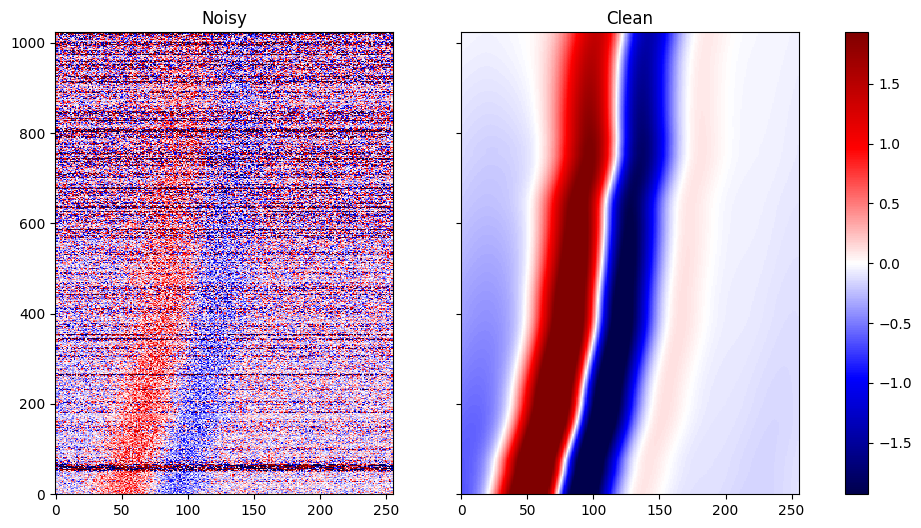

In [16]:
y = np.load("noisy_signal.npy")
print(y.shape)
x = np.load("clean_signal.npy")
print(x.shape)
y = (y - y.mean()) / y.std()
y = torch.from_numpy(y).float()
x = (x - x.mean()) / x.std()
x = torch.from_numpy(x).float()
for i in range(y.shape[0]):
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
    v = np.percentile(np.abs(y), 95)
    axs[0].imshow(y[i].squeeze().numpy(), origin='lower', aspect='auto', cmap='seismic', interpolation='none', vmin=-v, vmax=v)
    im = axs[1].imshow(x[i].squeeze().numpy(), origin='lower', aspect='auto', cmap='seismic', interpolation='none', vmin=-v, vmax=v)
    axs[0].set_title('Noisy')
    axs[1].set_title('Clean')

    fig.colorbar(im, ax=axs.ravel().tolist())
    plt.show()

In [17]:
print(y)
print(x)

tensor([[[[ 0.0781, -0.1328, -0.3114,  ...,  0.2981,  0.1405, -0.3208],
          [ 0.1250, -0.5359,  0.1117,  ...,  0.2472,  0.1734,  0.3359],
          [ 0.0382,  0.1222, -0.5444,  ..., -0.0277, -0.1164,  0.0151],
          ...,
          [-2.2410, -1.8015,  3.9600,  ..., -2.5770,  2.2764,  2.0591],
          [-0.7862,  0.3160,  1.1612,  ..., -1.5248, -0.8564,  1.0818],
          [ 0.1900, -0.6795, -1.3746,  ..., -0.8320,  0.6948, -0.6093]]]])
tensor([[[[-0.6556, -0.6495, -0.6417,  ..., -0.1056, -0.1029, -0.0996],
          [-0.6552, -0.6492, -0.6415,  ..., -0.1057, -0.1030, -0.0997],
          [-0.6547, -0.6488, -0.6413,  ..., -0.1058, -0.1031, -0.0998],
          ...,
          [-0.0305, -0.0316, -0.0326,  ..., -0.0497, -0.0507, -0.0516],
          [-0.0301, -0.0312, -0.0323,  ..., -0.0496, -0.0506, -0.0515],
          [-0.0298, -0.0309, -0.0319,  ..., -0.0495, -0.0505, -0.0514]]]])


cuda
Epoch 500: total_loss=1.175322e+05
Epoch 1000: total_loss=1.175457e+05
Learning rate is reduced to 0.0008
Epoch 1500: total_loss=1.175146e+05
Epoch 2000: total_loss=1.175220e+05
Epoch 2500: total_loss=1.174619e+05
Learning rate is reduced to 0.00064
Epoch 3000: total_loss=1.174622e+05
Epoch 3500: total_loss=1.174573e+05
Learning rate is reduced to 0.0005120000000000001
Epoch 4000: total_loss=1.174687e+05
Epoch 4500: total_loss=1.174660e+05
Epoch 5000: total_loss=1.175038e+05
Learning rate is reduced to 0.0004096000000000001
Epoch 5500: total_loss=1.174030e+05
Epoch 6000: total_loss=1.174496e+05
Learning rate is reduced to 0.0003276800000000001
Epoch 6500: total_loss=1.174078e+05
Epoch 7000: total_loss=1.173578e+05
Epoch 7500: total_loss=1.174564e+05
Learning rate is reduced to 0.0002621440000000001
Epoch 8000: total_loss=1.174500e+05
Epoch 8500: total_loss=1.174471e+05
Learning rate is reduced to 0.00020971520000000012
Epoch 9000: total_loss=1.173763e+05
Epoch 9500: total_loss=1.1

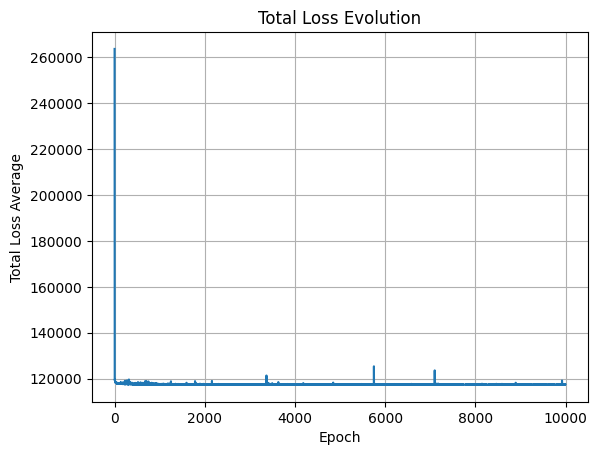

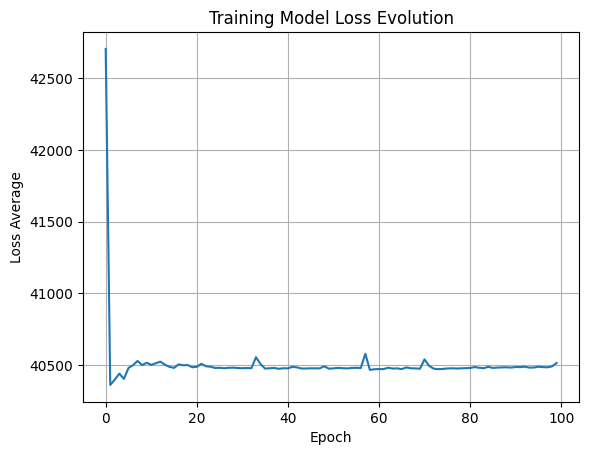

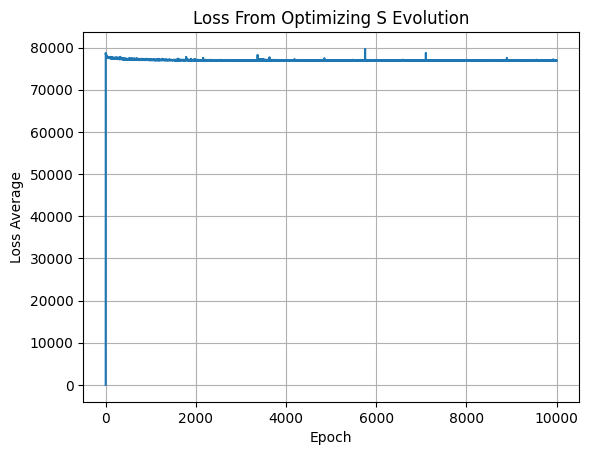

In [18]:
model, S_est, M_est, H_est = train(y,
                                   lr_model=1e-3,
                                   decay=0.8,
                                   g1=1,
                                   g2=1,
                                   n_epoch=10000,
                                   it_model=1,
                                   tol=1e-10,
                                   decay_interval=1250,
                                   init_w=0.2)

In [19]:
torch.save(model.state_dict(), "./Results/SM/syn/model_synthtetic_data")

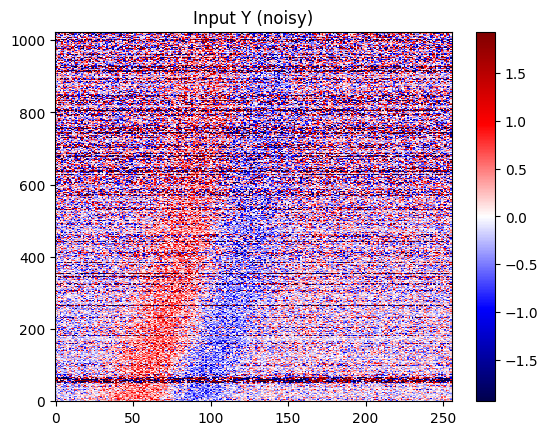

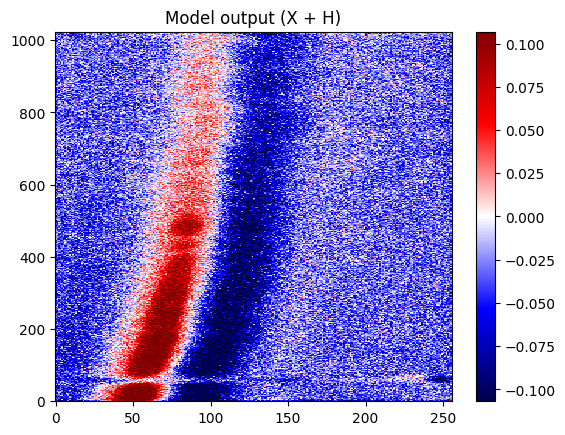

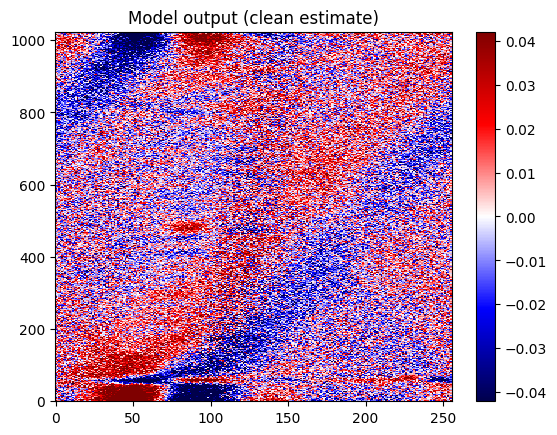

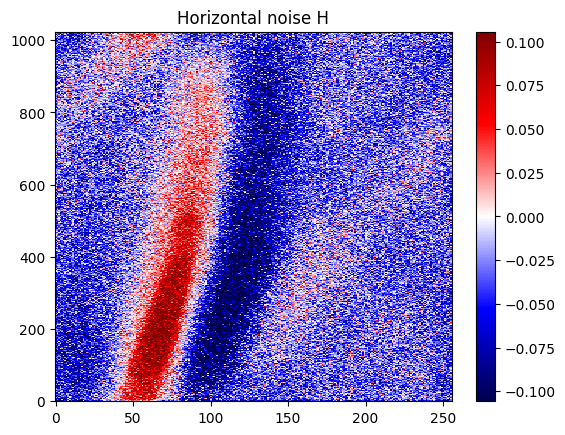

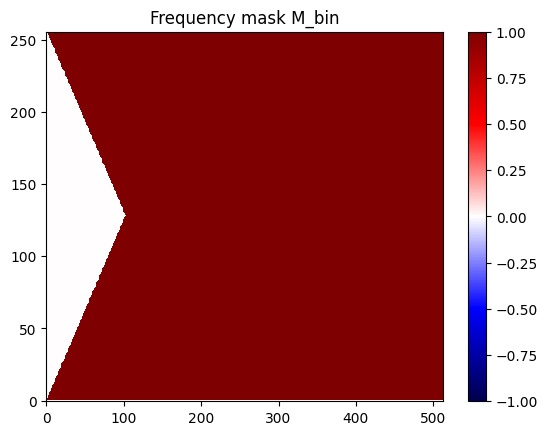

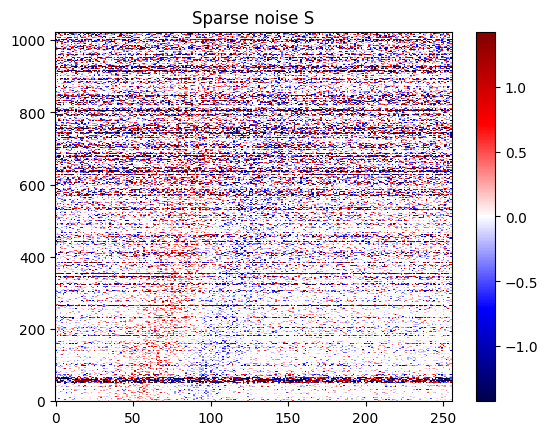

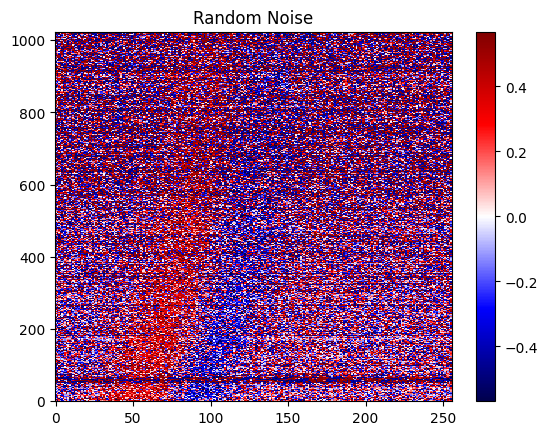

In [20]:
def show_tensor(tensor, title, name):
    t_np = tensor.squeeze().cpu().detach().numpy()
    v = np.percentile(np.abs(t_np), 95)
    plt.imshow(t_np, cmap='seismic', aspect='auto', origin='lower', interpolation='none', vmin=-v, vmax=v)
    plt.colorbar()
    plt.title(title)
    plt.savefig(f'./Results/SM/syn/{name}.png')
    plt.show()
    
device = next(model.parameters()).device
y_device = y.to('cuda')
clean_sig = infer(model, y_device, M_est, 100)
XH = infer(model, y_device, M_est, 100, False)
H_est = XH - clean_sig
N_est = y_device - XH - S_est
show_tensor(y_device, "Input Y (noisy)", f'Y')
show_tensor(XH, "Model output (X + H)", f'XH')
show_tensor(clean_sig, "Model output (clean estimate)", f'X')
show_tensor(H_est, "Horizontal noise H", f'H')
show_tensor(M_est, "Frequency mask M_bin", f'M')
show_tensor(S_est, "Sparse noise S", f'S')
show_tensor(N_est, "Random Noise", f'N')
torch.save(M_est, f"./Results/SM/syn/mask")

In [21]:
SNR = 10 * torch.log10((torch.norm(y_device, p=2)/torch.norm(N_est+H_est+S_est, p=2))).item()
print(SNR)

0.0025117656332440674
